Sometimes ZTE images are created with inverted contrast. petra2density assumes a non-inverted image to create the pCT/density image. Something like the code below can be used to invert the contrast back.

In [7]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [10]:
path = "../data/zte.nii.gz"
image = nib.load(path)
data = image.get_fdata()

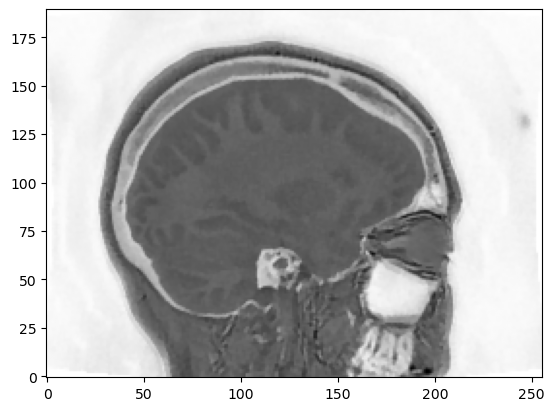

In [18]:
plt.imshow(data[100, ...].T, cmap="gray", origin="lower");

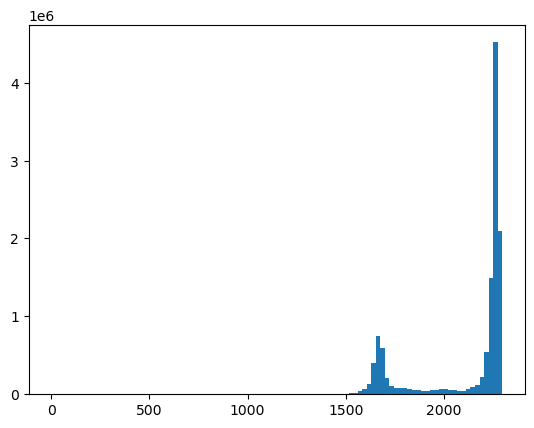

In [11]:
plt.hist(data.flatten(), bins=100);

In [12]:
data_inv = - data + data.max()

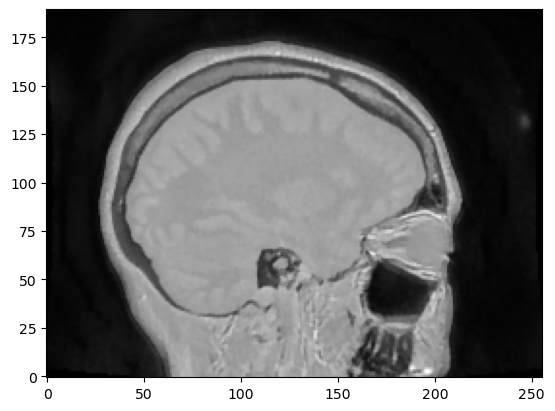

In [19]:
plt.imshow(data_inv[100, ...].T, cmap="gray", origin="lower");

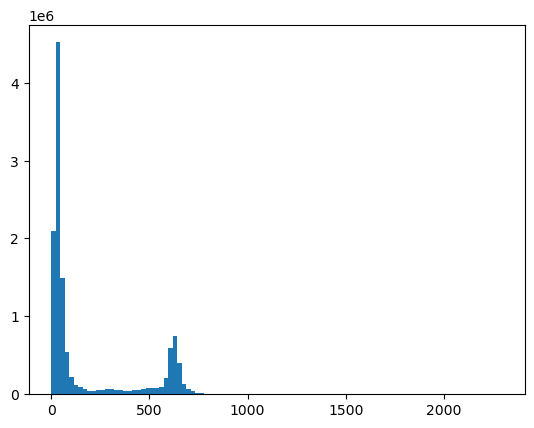

In [13]:
plt.hist(data_inv.flatten(), bins=100);

In [20]:
image_inv = nib.Nifti1Pair(data_inv, image.affine, image.header)
out_path = path.replace(".nii", "_inv.nii")
nib.save(image_inv, out_path)